# **Multi Layered Neural Network and Backpropogation**

 1. **Chapter 4:, page no. 106-136, Artificial Neural Network by B. Yegnanarayana)**

  2. https://machinelearningmastery.com/implement-backpropagation-algorithm-scratch-python/

  3. https://www.geeksforgeeks.org/deep-neural-net-with-forward-and-back-propagation-from-scratch-python/

  4. https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html

  5. https://towardsdatascience.com/the-vanishing-gradient-problem-69bf08b15484

#**Problem 1** : Demonstrate the working principle of multi layered neural network, with non-linearly separable data.

Observation to be demonstrated:
1. Two layer neural network (i.e one input and one output layer) is not able to classify non-linearly separable data. Solve the problem by increasing the no. of layers and changing the activation function from hard-limiting to sigmoid.

## Programming :
Please write a program to demonstrate:

**Step 1** : Data Generation: Generate Non-Linearly Separable data

**Step 2** : Demonstrate how two layered neural network (perceptron without a hidden layer) fails to classify non-linearly separable data.

**Step 3** : Demonstrate how addition of a hidden layer helps in overcoming this problem (Backpropogation).

In [68]:
import numpy as np
import sklearn.datasets as dt
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from random import seed

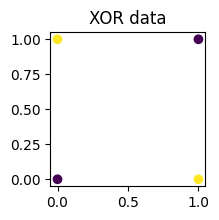

In [69]:
def XORdata():

  x_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
  y_xor = np.array([-1, 1, 1, -1])

  return x_xor,y_xor

x_xor,y_xor = XORdata()


plt.figure(figsize=(2,2))
my_scatter_plot = plt.scatter(x_xor[:, 0],
                              x_xor[:, 1],
                              c=y_xor,
                              vmin=0,
                              vmax=1,
                              )
plt.title("XOR data")
plt.show()



# With two layers (one input and one output)

In [70]:
# Write your training code here
import torch.nn.functional as F

# Create a Model Class that inherits nn.Module
class TwoLayerModel(nn.Module):
  # Input layer (4 features of the flower) -->
  # Hidden Layer1 (number of neurons) -->
  # output
  def __init__(self, in_features=2, output=1):
    super().__init__() # instantiate our nn.Module
    self.fc1 = nn.Linear(in_features, output)
    
  def forward(self, x):
    x = self.fc1(x)
    return x

# Create an instance of model
modelTwoLayered = TwoLayerModel()
     

# Convert X features to float tensors
X_train = torch.FloatTensor(x_xor)
y_train = torch.FloatTensor(y_xor).view(-1, 1)

# Set the criterion of model to measure the error, how far off the predictions are from the data
criterion = nn.MSELoss()
# Choose Adam Optimizer, lr = learning rate (if error doesn't go down after a bunch of iterations (epochs), lower our learning rate)
optimizer = torch.optim.SGD(modelTwoLayered.parameters(), lr=0.1)


epochs = 100
losses = []
for i in range(epochs):
  # Go forward and get a prediction
  y_pred = modelTwoLayered.forward(X_train) # Get predicted results

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train) # predicted values vs the y_train

  # Keep Track of our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it back
  # thru the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and loss: 1.0376427173614502
Epoch: 10 and loss: 1.0027586221694946
Epoch: 20 and loss: 1.001024603843689
Epoch: 30 and loss: 1.0003888607025146
Epoch: 40 and loss: 1.0001506805419922
Epoch: 50 and loss: 1.0000600814819336
Epoch: 60 and loss: 1.000024676322937
Epoch: 70 and loss: 1.0000104904174805
Epoch: 80 and loss: 1.0000046491622925
Epoch: 90 and loss: 1.000002145767212


Text(0.5, 0, 'Epoch')

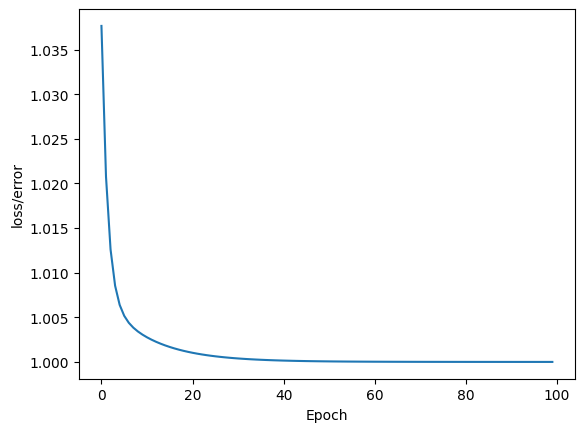

In [71]:
# Graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

### Testing the trained network

Predicted output from 2 -layer network:
tensor([[ 0.0015],
        [ 0.0010],
        [-0.0005],
        [-0.0010]], grad_fn=<AddmmBackward0>)


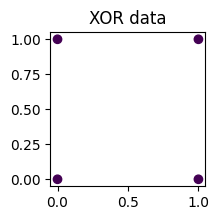

In [72]:
# Write your testing code here
print("Predicted output from 2 -layer network:")
y_results_two_layered = []
with torch.no_grad():
    y_results_two_layered.append(modelTwoLayered(X_train).numpy())
    
print(y_pred)

plt.figure(figsize=(2,2))
my_scatter_plot = plt.scatter(x_xor[:, 0],
                              x_xor[:, 1],
                              c=y_results_two_layered,
                              vmin=0,
                              vmax=1,
                              )
plt.title("XOR data")
plt.show()

# With three layers (one input, one hidden and one output)

**Solving XOR problem using 3 Layered Network**

In [73]:
# Write your training code here
# Write your training code here
import torch.nn.functional as F

# Create a Model Class that inherits nn.Module
class ThreeLayerModel(nn.Module):
  # Input layer -->
  # Hidden Layer1 (number of neurons) -->
  # output
  def __init__(self, in_features=2, h1 = 10, output=1):
    super().__init__() # instantiate our nn.Module
    self.fc1 = nn.Linear(in_features, h1) # hidden layer with 10 nodes
    self.out = nn.Linear(h1, output)
    
  def forward(self, x):
    x = torch.sigmoid(self.fc1(x))
    x = torch.tanh(self.out(x))
    return x

# Create an instance of model
modelThreeLayered = ThreeLayerModel()
    

# Set the criterion of model to measure the error, how far off the predictions are from the data
criterion = nn.MSELoss()
# Choose Adam Optimizer, lr = learning rate (if error doesn't go down after a bunch of iterations (epochs), lower our learning rate)
optimizer = torch.optim.Adam(modelThreeLayered.parameters(), lr=0.1)

**Testing with the trained network**

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
tensor([[-1.],
        [ 1.],
        [ 1.],
        [-1.]])
Epoch: 0 and loss: 1.0411748886108398
Epoch: 1000 and loss: 4.825579890166409e-05
Epoch: 2000 and loss: 1.3318570381670725e-05
Epoch: 3000 and loss: 5.64101901545655e-06
Epoch: 4000 and loss: 2.810698106259224e-06
Epoch: 5000 and loss: 1.51553194882581e-06
Epoch: 6000 and loss: 8.530569743925298e-07
Epoch: 7000 and loss: 4.922028438159032e-07
Epoch: 8000 and loss: 2.882472358578525e-07
Epoch: 9000 and loss: 1.703772767314149e-07
Predicted output from 3 -layer network:
[array([[-0.99976414],
       [ 0.9996921 ],
       [ 0.9996822 ],
       [-0.99960786]], dtype=float32)]


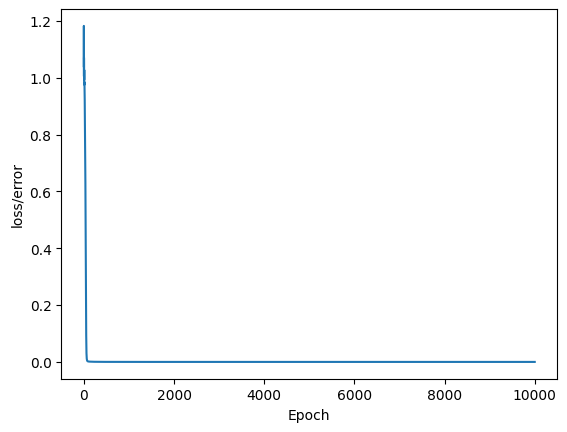

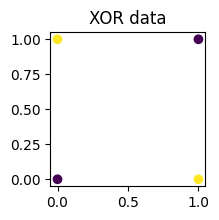

In [74]:
# Write your testing code here
epochs = 10000
losses = []# Convert X features to float tensors
X_train = torch.FloatTensor(x_xor)
y_train = torch.FloatTensor(y_xor).view(-1,1)

print(X_train)
print(y_train)

for i in range(epochs):
  # Go forward and get a prediction
  y_pred = modelThreeLayered.forward(X_train) # Get predicted results

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train) # predicted values vs the y_train

  # Keep Track of our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 1000 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it back
  # thru the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  
# Graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

print("Predicted output from 3 -layer network:")
y_results = []
with torch.no_grad():
    y_results.append(modelThreeLayered(X_train).numpy())
    
print(y_results)


#nteger_tensor.flatten().numpy()

plt.figure(figsize=(2,2))
my_scatter_plot = plt.scatter(x_xor[:, 0],
                              x_xor[:, 1],
                              c=y_results,
                              vmin=0,
                              vmax=1,
                              )
plt.title("XOR data")
plt.show()

# Inferences:



Here we see that as the data in XOR is not linearly separable, the network is not able to learn with a 2 layer neural network. When it is converted in a 3 layer neural network and trained over a longer time, the model is able to learn perfectly to classify the XOR data

#Problem 2** : Demonstrate the working principle of multi layered neural network for non-convex data.

Observations to be demonstrated:
1. Three layered neural networks (i.e one hidden and one output layer) are not able to model non-convex data.

2. Solve the problem by increasing the number of layers.


References:
1. **Chapter 4:, page no. 106-136, Artificial Neural Network by B. Yegnanarayana)**


**Step 1** : Data Generation: Generate Non-convex data.

**Step 2** : Demonstrate how two layered neural network (one hidden layer and one output layer) fails to classify non-convex data.

**Step 3** : Demonstrate how addition of another hidden layer helps in overcoming this problem.

In [75]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

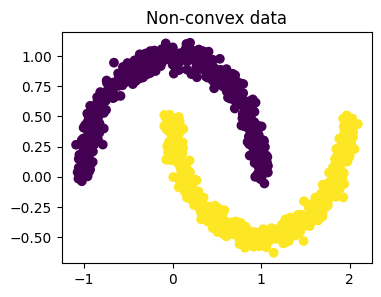

In [76]:
noisy_moons = datasets.make_moons(n_samples=1000, noise=0.05)

x,y=noisy_moons
y = y.reshape(y.shape[0], 1)
plt.figure(figsize=(4,3))
plt.scatter(x[:, 0],x[:, 1],c=y,vmin=0,vmax=1)
plt.title("Non-convex data")
plt.show()

# Previous method: 3 layers (one input, one hidden and one output)

Epoch: 0 and loss: 0.2783013582229614
Epoch: 1000 and loss: 0.2783013582229614
Epoch: 2000 and loss: 0.2783013582229614
Epoch: 3000 and loss: 0.2783013582229614
Epoch: 4000 and loss: 0.2783013582229614
Epoch: 5000 and loss: 0.2783013582229614
Epoch: 6000 and loss: 0.2783013582229614
Epoch: 7000 and loss: 0.2783013582229614
Epoch: 8000 and loss: 0.2783013582229614
Epoch: 9000 and loss: 0.2783013582229614
Predicted output from 3 -layer network:


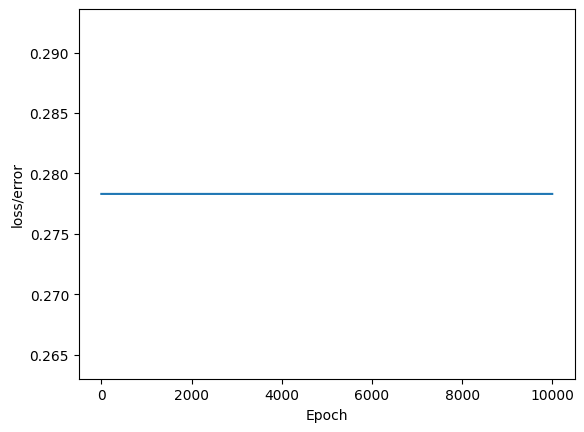

In [77]:
# Write your training code here
# Create an instance of model
modelThreeLayered = ThreeLayerModel(in_features=2, h1 = 10, output=1)

# Write your testing code here
epochs = 10000
losses = []# Convert X features to float tensors
X_train = torch.FloatTensor(x)
y_train = torch.FloatTensor(y)

# print(X_train)
# print(y_train)

for i in range(epochs):
  # Go forward and get a prediction
  y_pred = modelThreeLayered.forward(X_train) # Get predicted results

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train) # predicted values vs the y_train

  # Keep Track of our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 1000 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it back
  # thru the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  
# Graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

print("Predicted output from 3 -layer network:")
y_results = []
with torch.no_grad():
    y_results.append(modelThreeLayered(X_train).numpy())
    
#print(y_results)

### Testing with trained network

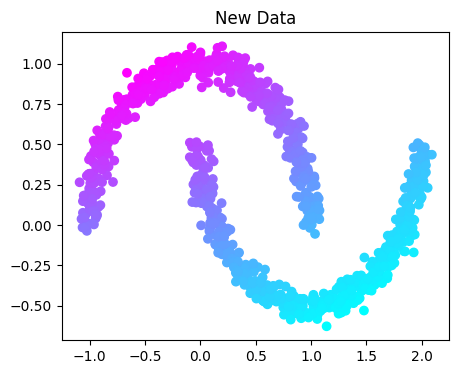

In [78]:
# Plot new data on a separate plot
plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_results, cmap='cool')
plt.title("New Data")
plt.show()


### **Using 4 layers (one input, two hidden, one output)**
Note: Pytorch is used for implementation.

Reference: https://pytorch.org/tutorials/

Epoch: 0 and loss: 0.25214526057243347
Epoch: 1000 and loss: 5.406962827692041e-06
Epoch: 2000 and loss: 1.4108384220890002e-06
Epoch: 3000 and loss: 5.772151894234412e-07
Epoch: 4000 and loss: 2.803111556204385e-07
Epoch: 5000 and loss: 1.4808429682489077e-07
Epoch: 6000 and loss: 8.195218015316641e-08
Epoch: 7000 and loss: 4.6614442084091934e-08
Epoch: 8000 and loss: 2.6969535937837463e-08
Epoch: 9000 and loss: 1.5777446904507997e-08
Predicted output from 4-layer network:


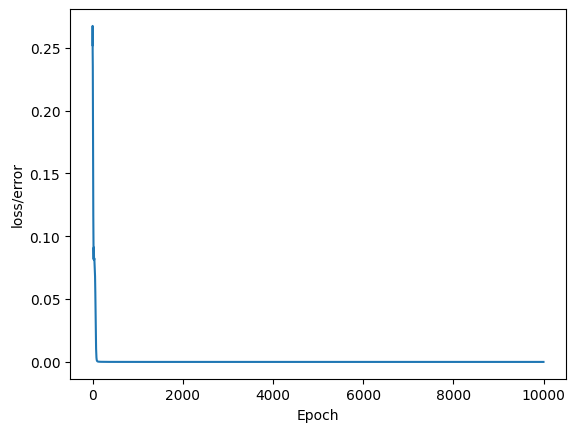

In [79]:
# Write your training code here

# Write your training code here
# Write your training code here
import torch.nn.functional as F

# Create a Model Class that inherits nn.Module
class FourLayerModel(nn.Module):
  # Input layer -->
  # Hidden Layer1 (number of neurons) -->
  # output
  def __init__(self, in_features=2, h1 = 10, h2=10, output=1):
    super().__init__() # instantiate our nn.Module
    self.fc1 = nn.Linear(in_features, h1) # hidden layer with 10 nodes
    self.fc2 = nn.Linear(h1, h2) # hidden layer with 10 nodes
    self.out = nn.Linear(h2, output)
    
  def forward(self, x):
    x = torch.sigmoid(self.fc1(x))
    x = torch.sigmoid(self.fc2(x))
    x = torch.sigmoid(self.out(x))
    return x

# Create an instance of model
modelFourLayered = FourLayerModel()
    

# Set the criterion of model to measure the error, how far off the predictions are from the data
criterion = nn.MSELoss()
# Choose Adam Optimizer, lr = learning rate (if error doesn't go down after a bunch of iterations (epochs), lower our learning rate)
optimizer = torch.optim.Adam(modelFourLayered.parameters(), lr=0.1)




# Write your testing code here
epochs = 10000
losses = []# Convert X features to float tensors
X_train = torch.FloatTensor(x)
y_train = torch.FloatTensor(y)

# print(X_train)
# print(y_train)

for i in range(epochs):
  # Go forward and get a prediction
  y_pred = modelFourLayered.forward(X_train) # Get predicted results

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train) # predicted values vs the y_train

  # Keep Track of our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 1000 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it back
  # thru the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  
# Graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

print("Predicted output from 4-layer network:")
y_results = []
with torch.no_grad():
    y_results.append(modelFourLayered(X_train).numpy())
    
#print(y_results)

### Tesing using trained network

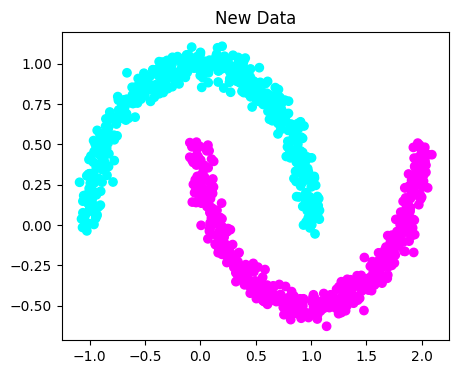

In [80]:
# Write your testing code here
# Plot new data on a separate plot
plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_results, cmap='cool')
plt.title("New Data")
plt.show()

# Inference

By increasing the complexity of the model, it is about to learn this non-convex data. With increaing the layer from 3-4 it is able to learn properly.

#**Problem 3** : Demonstrate the working principle of multi layered neural network for concentric-circles data.

Observations to be demonstrated:
1. Four layered NN with sigmoid activation is not able to model concentric-circles data.

2. Problem of vanishing gradient occurs when number of layers are large.

3. Solve the problem by replacing sigmoid with Relu.


References:
1. **Chapter 4:, page no. 106-136, Artificial Neural Network by B. Yegnanarayana)**
2. For plotting average gradients per layer https://discuss.pytorch.org/t/check-gradient-flow-in-network/15063/6


In [81]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

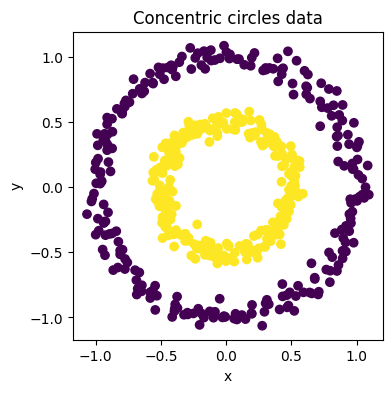

In [82]:
n_samples = 500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)

x,y=noisy_circles
y = y.reshape(y.shape[0], 1)
plt.figure(figsize=(4,4))
plt.scatter(x[:, 0],x[:, 1],c=y,vmin=0,vmax=1)
plt.title("Concentric circles data")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### **Using 4 layers (one input, two hidden, one output) with sigmoid activation function**
Note: Pytorch is used for implementation.

Reference: https://pytorch.org/tutorials/

Epoch: 0 and loss: 0.2592948377132416
Epoch: 1000 and loss: 0.2499874234199524
Epoch: 2000 and loss: 0.2499874085187912
Epoch: 3000 and loss: 0.2499874234199524
Epoch: 4000 and loss: 0.34599998593330383
Epoch: 5000 and loss: 0.34599998593330383
Epoch: 6000 and loss: 0.34599998593330383
Epoch: 7000 and loss: 0.34599998593330383
Epoch: 8000 and loss: 0.34599998593330383
Epoch: 9000 and loss: 0.34599998593330383
Predicted output from 4-layer network:


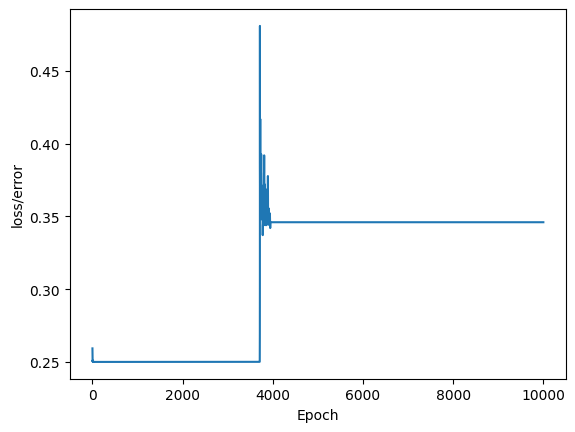

In [83]:
# Write your training code here
# Write your training code here

# Write your training code here
# Write your training code here
import torch.nn.functional as F

# Create a Model Class that inherits nn.Module
class FourLayerModel(nn.Module):
  # Input layer -->
  # Hidden Layer1 (number of neurons) -->
  # output
  def __init__(self, in_features=2, h1 = 10, h2=10, output=1):
    super().__init__() # instantiate our nn.Module
    self.fc1 = nn.Linear(in_features, h1) # hidden layer with 10 nodes
    self.fc2 = nn.Linear(h1, h2) # hidden layer with 10 nodes
    self.out = nn.Linear(h2, output)
    
  def forward(self, x):
    x = self.fc1(x)
    x = self.fc2(x)
    x = torch.sigmoid(self.out(x))
    return x

# Create an instance of model
modelFourLayered = FourLayerModel()
    

# Set the criterion of model to measure the error, how far off the predictions are from the data
criterion = nn.MSELoss()
# Choose Adam Optimizer, lr = learning rate (if error doesn't go down after a bunch of iterations (epochs), lower our learning rate)
optimizer = torch.optim.Adam(modelFourLayered.parameters(), lr=0.1)




# Write your testing code here
epochs = 10000
losses = []# Convert X features to float tensors
gradients = []

X_train = torch.FloatTensor(x)
y_train = torch.FloatTensor(y)

# print(X_train)
# print(y_train)

for i in range(epochs):
  # Go forward and get a prediction
  y_pred = modelFourLayered.forward(X_train) # Get predicted results

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train) # predicted values vs the y_train

  # Keep Track of our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 1000 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it back
  # thru the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()

  # Record the gradient magnitudes for the first layer (fc1) as an example
  total_grad = 0
  for param in modelFourLayered.parameters():
      total_grad += param.grad.abs().mean().item()
  gradients.append(total_grad)
  
  optimizer.step()
  
# Graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

print("Predicted output from 4-layer network:")
y_results = []
with torch.no_grad():
    y_results.append(modelFourLayered(X_train).numpy())
    
#print(y_results)

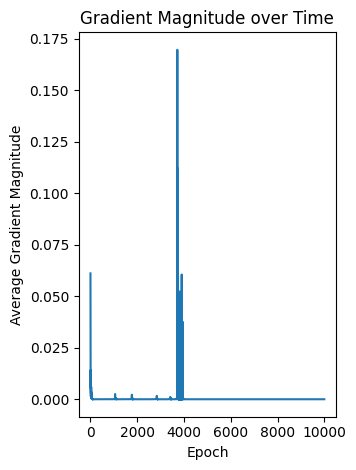

In [84]:
#Plot Gradients
plt.subplot(1, 2, 2)
plt.plot(range(epochs), gradients)
plt.title('Gradient Magnitude over Time')
plt.xlabel('Epoch')
plt.ylabel('Average Gradient Magnitude')

plt.tight_layout()
plt.show()

The above figure shows the **Vanishing gradient problem**.
The computed gradient values are almost zero at the first layer.

Here also the loss is plateuing which shows the vanishing gradient problem

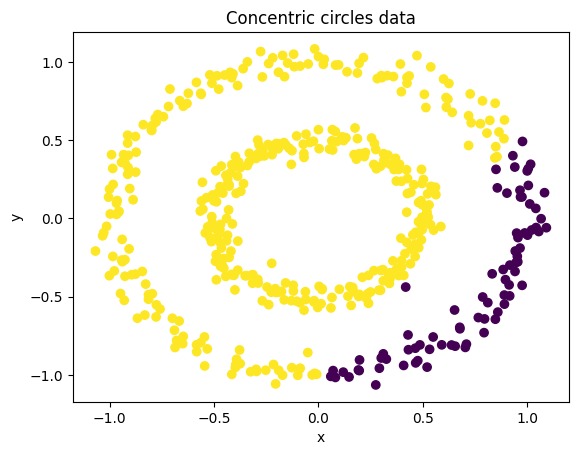

In [85]:
# Write your testing code here
plt.scatter(X_train[:, 0],X_train[:, 1],c=y_results,vmin=0,vmax=1)
plt.title("Concentric circles data")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# **With ReLU activation**
Solving vanishing gradient problem with ReLU activation function.

Epoch: 0 and loss: 0.4567500054836273
Epoch: 1000 and loss: 8.362103835679591e-05
Epoch: 2000 and loss: 6.116811709944159e-05
Epoch: 3000 and loss: 1.3472775208356325e-05
Epoch: 4000 and loss: 3.928413207177073e-05
Epoch: 5000 and loss: 1.2578084351844154e-06
Epoch: 6000 and loss: 9.475900878896937e-05
Epoch: 7000 and loss: 0.00024154492712114006
Epoch: 8000 and loss: 5.056281224824488e-07
Epoch: 9000 and loss: 9.658854196459288e-07
Predicted output from 4-layer network:


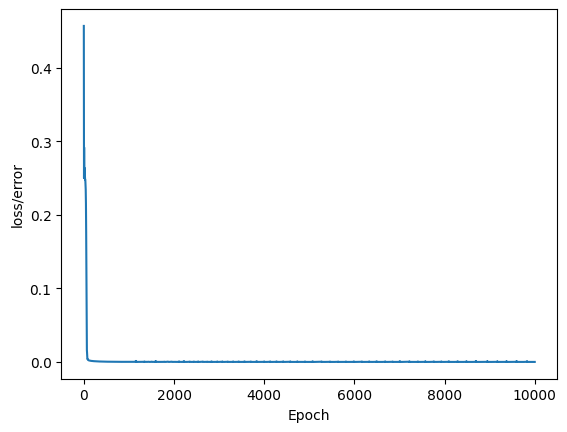

In [86]:
# Write your training code here
# Write your training code here
import torch.nn.functional as F

# Create a Model Class that inherits nn.Module
class FourLayerModel(nn.Module):
  # Input layer -->
  # Hidden Layer1 (number of neurons) -->
  # output
  def __init__(self, in_features=2, h1 = 10, h2=10, output=1):
    super().__init__() # instantiate our nn.Module
    self.fc1 = nn.Linear(in_features, h1) # hidden layer with 10 nodes
    self.fc2 = nn.Linear(h1, h2) # hidden layer with 10 nodes
    self.out = nn.Linear(h2, output)
    
  def forward(self, x):
    x = torch.sigmoid(self.fc1(x))
    x = torch.sigmoid(self.fc2(x))
    x = torch.relu(self.out(x))
    return x

# Create an instance of model
modelFourLayered = FourLayerModel()
    

# Set the criterion of model to measure the error, how far off the predictions are from the data
criterion = nn.MSELoss()
# Choose Adam Optimizer, lr = learning rate (if error doesn't go down after a bunch of iterations (epochs), lower our learning rate)
optimizer = torch.optim.Adam(modelFourLayered.parameters(), lr=0.1)




# Write your testing code here
epochs = 10000
losses = []# Convert X features to float tensors
gradients = []
grad_fc1 = []
grad_fc2 = []
grad_out = []

X_train = torch.FloatTensor(x)
y_train = torch.FloatTensor(y)

# print(X_train)
# print(y_train)

for i in range(epochs):
  # Go forward and get a prediction
  y_pred = modelFourLayered.forward(X_train) # Get predicted results

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train) # predicted values vs the y_train

  # Keep Track of our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 1000 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it back
  # thru the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()

    # Record the gradient magnitudes for the first layer (fc1) as an example
  total_grad = 0
  for param in modelFourLayered.parameters():
      total_grad += param.grad.abs().mean().item()
  gradients.append(total_grad)

# Record the gradient magnitudes for each layer
  grad_fc1.append(modelFourLayered.fc1.weight.grad.abs().mean().item())
  grad_fc2.append(modelFourLayered.fc2.weight.grad.abs().mean().item())
  grad_out.append(modelFourLayered.out.weight.grad.abs().mean().item())

  optimizer.step()
  
# Graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

print("Predicted output from 4-layer network:")
y_results = []
with torch.no_grad():
    y_results.append(modelFourLayered(X_train).numpy())
    
#print(y_results)

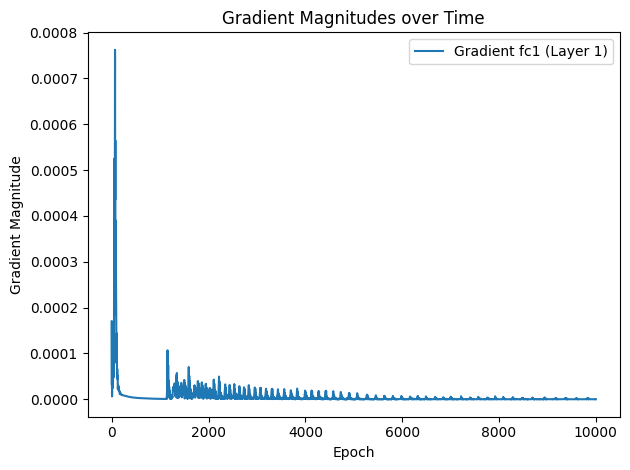

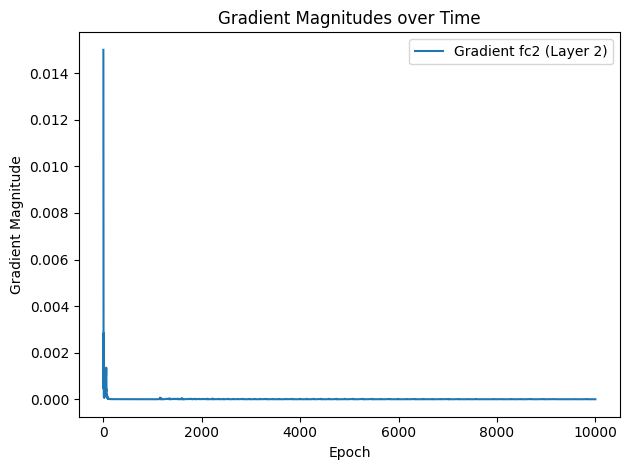

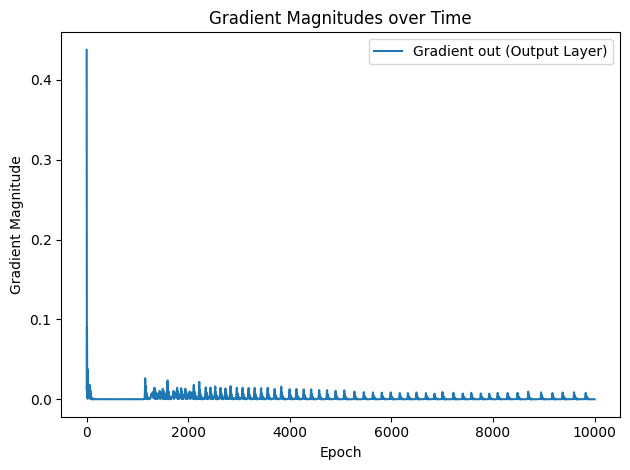

In [87]:
# Plot Gradients for each layer

plt.plot(range(epochs), grad_fc1, label='Gradient fc1 (Layer 1)')
plt.title('Gradient Magnitudes over Time')
plt.xlabel('Epoch')
plt.ylabel('Gradient Magnitude')
plt.legend()

plt.tight_layout()
plt.show()


plt.plot(range(epochs), grad_fc2, label='Gradient fc2 (Layer 2)')
plt.title('Gradient Magnitudes over Time')
plt.xlabel('Epoch')
plt.ylabel('Gradient Magnitude')
plt.legend()

plt.tight_layout()
plt.show()

plt.plot(range(epochs), grad_out, label='Gradient out (Output Layer)')
plt.title('Gradient Magnitudes over Time')
plt.xlabel('Epoch')
plt.ylabel('Gradient Magnitude')
plt.legend()

plt.tight_layout()
plt.show()

From the above plot, we can see that the vanishing gradient problem has been solved. The gradient values are reaching the first layer.

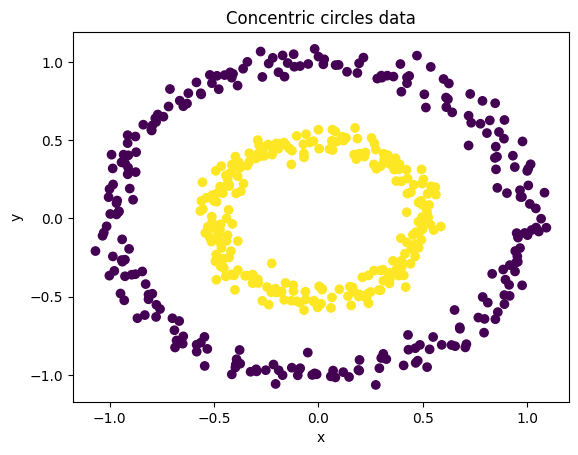

In [88]:
# Write your testing code here
# Write your testing code here
plt.scatter(X_train[:, 0],X_train[:, 1],c=y_results,vmin=0,vmax=1)
plt.title("Concentric circles data")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

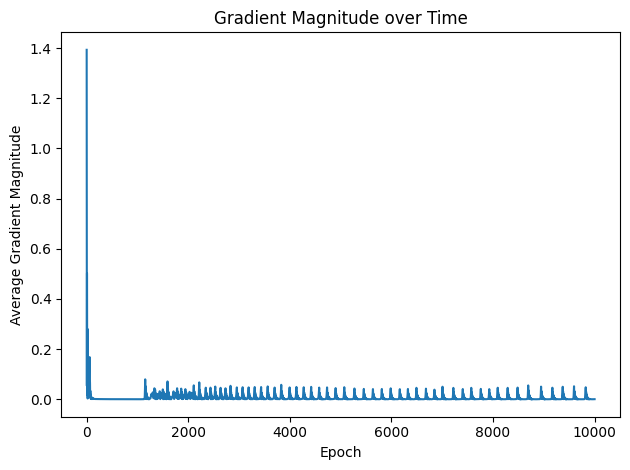

In [89]:
#Plot Gradients
plt.plot(range(epochs), gradients)
plt.title('Gradient Magnitude over Time')
plt.xlabel('Epoch')
plt.ylabel('Average Gradient Magnitude')

plt.tight_layout()
plt.show()

# Inference

It is seen that the use of RELU decreases the vanishing gradient problem. With the back propagattion the gradients becomes zero from higher layers to the lower layers. Thus Relu helps in fixing the anishng gradient problem, because it does not let the gradient become zero.